In [3]:


# You’re optimising a cake recipe using a black-box function with five ingredient inputs, 
# for example flour, sugar, eggs, butter and milk. Each recipe is evaluated with a combined score 
# based on flavour, consistency, calories, waste and cost, where each factor contributes negative points 
# as judged by an expert taster. This means the total score is negative by design. 

# To frame this as a maximisation problem, your goal is to bring that score as close to zero as possible or, 
# equivalently, to maximise the negative of the total sum.

#  x1     x2    x3    x4      x5
# flour sugar  eggs  butter  milk

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

X = np.load('initial_inputs.npy')
y = np.load('initial_outputs.npy')

week1_X = [0.315938, 0.017065, 0.899154, 0.923548, 0.050946]
week1_y = -0.9319781034031738

X = np.vstack([X, week1_X])
y = np.append(y, week1_y)

print('-- inputs X ---')
print(X)
print("X shape=",X.shape)

print('-- outputs y ---')
print(y)
print("y shape=",y.shape)

# Set random seed for reproducibility
np.random.seed(42)

-- inputs X ---
[[0.7281861  0.15469257 0.73255167 0.69399651 0.05640131]
 [0.24238435 0.84409997 0.5778091  0.67902128 0.50195289]
 [0.72952261 0.7481062  0.67977464 0.35655228 0.67105368]
 [0.77062024 0.11440374 0.04677993 0.64832428 0.27354905]
 [0.6188123  0.33180214 0.18728787 0.75623847 0.3288348 ]
 [0.78495809 0.91068235 0.7081201  0.95922543 0.0049115 ]
 [0.14511079 0.8966846  0.89632223 0.72627154 0.23627199]
 [0.94506907 0.28845905 0.97880576 0.96165559 0.59801594]
 [0.12572016 0.86272469 0.02854433 0.24660527 0.75120624]
 [0.75759436 0.35583141 0.0165229  0.4342072  0.11243304]
 [0.5367969  0.30878091 0.41187929 0.38822518 0.5225283 ]
 [0.95773967 0.23566857 0.09914585 0.15680593 0.07131737]
 [0.6293079  0.80348368 0.81140844 0.04561319 0.11062446]
 [0.02173531 0.42808424 0.83593944 0.48948866 0.51108173]
 [0.43934426 0.69892383 0.42682022 0.10947609 0.87788847]
 [0.25890557 0.79367771 0.6421139  0.19667346 0.59310318]
 [0.43216593 0.71561781 0.3418191  0.70499988 0.61496184

In [5]:
# df = pd.DataFrame(X, columns=["x1","x2","x3","x4", "x5"])

df = pd.DataFrame(X, columns=["flour","sugar","eggs","butter", "milk"])
df['taste_score'] = y
df = df.sort_values(by='taste_score', ascending=False)

#  x1     x2    x3    x4      x5
# flour sugar  eggs  butter  milk
df

# week1 result 3rd in place
# 20	0.315938	0.017065	0.899154	0.923548	0.050946	-0.931978

,flour,sugar,eggs,butter,milk,taste_score
0,0.728186,0.154693,0.732552,0.693997,0.056401,-0.714265
4,0.618812,0.331802,0.187288,0.756238,0.328835,-0.829237
20,0.315938,0.017065,0.899154,0.923548,0.050946,-0.931978
17,0.782880,0.536336,0.443284,0.859700,0.010326,-0.935757
10,0.536797,0.308781,0.411879,0.388225,0.522528,-1.144785
1,0.242384,0.844100,0.577809,0.679021,0.501953,-1.209955
6,0.145111,0.896685,0.896322,0.726272,0.236272,-1.233786
5,0.784958,0.910682,0.708120,0.959225,0.004911,-1.247049
16,0.432166,0.715618,0.341819,0.705000,0.614962,-1.294247
9,0.757594,0.355831,0.016523,0.434207,0.112433,-1.309116


In [6]:
sorted_idx = np.argsort(y)[::-1]
best_idx      = sorted_idx[0]
second_idx    = sorted_idx[1]
third_idx     = sorted_idx[2]

x_best  = X[best_idx]
x_second_best = X[second_idx]
x_third_best  = X[third_idx]

y_best        = y[best_idx]
y_second_best = y[second_idx]
y_third_best  = y[third_idx]

print(sorted_idx)

print(f"Current Best x_idx: {best_idx}")
print(f"Current Best x:     {x_best},        y:{y_best}")
print(f"Current 2nd Best x: {x_second_best}, y:{y_second_best}")
print(f"Current 3nd Best x: {x_third_best},  y:{y_third_best}")

[ 0  4 20 17 10  1  6  5 16  9 13  3 12  2  7 15 19 11 14 18  8]
Current Best x_idx: 0
Current Best x:     [0.7281861  0.15469257 0.73255167 0.69399651 0.05640131],        y:-0.7142649478202404
Current 2nd Best x: [0.6188123  0.33180214 0.18728787 0.75623847 0.3288348 ], y:-0.8292365522578722
Current 3nd Best x: [0.315938 0.017065 0.899154 0.923548 0.050946],  y:-0.9319781034031738


In [7]:
def upper_confidence_bound(mu, sigma, kappa=2.0):
    """
    kappa = 1.96  -> 95% confidence (Balanced)
    kappa = 2.576 -> 99% confidence (More Exploration)
    """
    return mu + kappa * sigma
    
def expected_improvement(mu, sigma, y_best, xi=0.01):
    with np.errstate(divide='warn'):
        improvement = mu - y_best - xi
        Z = improvement / sigma
        ei = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)
        ei[sigma == 0.0] = 0.0
    return ei

In [8]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, ConstantKernel as C
from scipy.stats import norm
import warnings
from sklearn.exceptions import ConvergenceWarning

# Put this at the very top of your script
warnings.filterwarnings('ignore', category=ConvergenceWarning)

kernel = C(1.0, (1e-1, 10)) * Matern(length_scale=[0.5, 0.5, 0.5, 0.5, 0.5], 
                                      length_scale_bounds=(0.1, 10), 
                                      nu=2.5)

gp = GaussianProcessRegressor(kernel=kernel, alpha=0.1, normalize_y=True, n_restarts_optimizer=10)
gp.fit(X, y)

print(f"Optimized Kernel: {gp.kernel_}")
print(f"Training R^2 Score: {gp.score(X, y)}")
print(f"Total variance accounted for as noise: {gp.alpha}")

# Optimized Kernel: 2.52**2 * Matern(length_scale=[0.88, 2.21, 2.27, 2.09, 2.51], nu=2.5)
# Training R^2 Score: 0.9713335488010869
# Total variance accounted for as noise: 0.1

# week2 
# Optimized Kernel: 1.48**2 * Matern(length_scale=[0.579, 1.57, 1.2, 1.12, 1.35], nu=2.5)
# Training R^2 Score: 0.9758537066148666
# Total variance accounted for as noise: 0.1

# Optimized Kernel: 1.43**2 * Matern(length_scale=[0.498, 0.989, 1.03, 1.18, 1.05], nu=2.5)
# Training R^2 Score: 0.9995982580390889
# Total variance accounted for as noise: 0.01

Optimized Kernel: 1.48**2 * Matern(length_scale=[0.579, 1.57, 1.2, 1.12, 1.35], nu=2.5)
Training R^2 Score: 0.9758537066148666
Total variance accounted for as noise: 0.1


In [9]:
# Predict
X_grid = np.random.uniform(0, 1, size=(10000, 5))
mu, sigma = gp.predict(X_grid, return_std=True)

sigma = sigma.reshape(-1, 1)
mu = mu.reshape(-1, 1)

In [10]:
# kappa = 2.0 is a great starting point for week 1
kappa=2.0
ucb_values = upper_confidence_bound(mu, sigma, kappa)


ucb_next_idx = np.argmax(ucb_values)
ucb_next_query = X_grid[ucb_next_idx]

print(f"UCB Score with kappa: {kappa}")
print(f"Current Best y: {y.max()}")
print(f"Suggested next: {ucb_next_query}")
# best combination so far 
#     x1      x2        x3          x4         x5            y
#    flour   sugar     eggs       butter      milk       taste_score
# 0.728186	0.154693  0.732552	0.693997	0.056401	-0.714265
# Suggested next: 
#     x1          x2          x3         x4       x5        
#    flour   sugar     eggs       butter      milk       
# [0.2267747  0.04948271 0.99466139 0.98223633 0.01118743]

UCB Score with kappa: 2.0
Current Best y: -0.7142649478202404
Suggested next: [0.42549333 0.34593499 0.37103876 0.98764956 0.04010919]


In [11]:
xi=0.01
ei_values = expected_improvement(mu, sigma, y_best, xi)

# Get the next best point
ei_next_idx = np.argmax(ei_values)
ei_next_query = X_grid[ei_next_idx]

print(f"expected_improvement with xi: {xi}")
print(f"Current Best y: {y.max()}")
print(f"Suggested next: {ei_next_query}")

# best combination so far 
#     x1      x2        x3          x4         x5            y
#    flour   sugar     eggs       butter      milk       taste_score
# 0.728186	0.154693  0.732552	0.693997	0.056401	-0.714265
# Suggested next: 
#     x1          x2          x3         x4       x5        
#    flour   sugar     eggs       butter      milk       
# [0.44454642 0.03013267 0.91531507 0.95841378 0.08393906]

# expected_improvement with xi: 0.01
# Current Best y: -0.7142649478202404
# Suggested next: [0.44454642 0.03013267 0.91531507 0.95841378 0.08393906]

expected_improvement with xi: 0.01
Current Best y: -0.7142649478202404
Suggested next: [0.56646661 0.14938455 0.46916605 0.83112722 0.01548246]


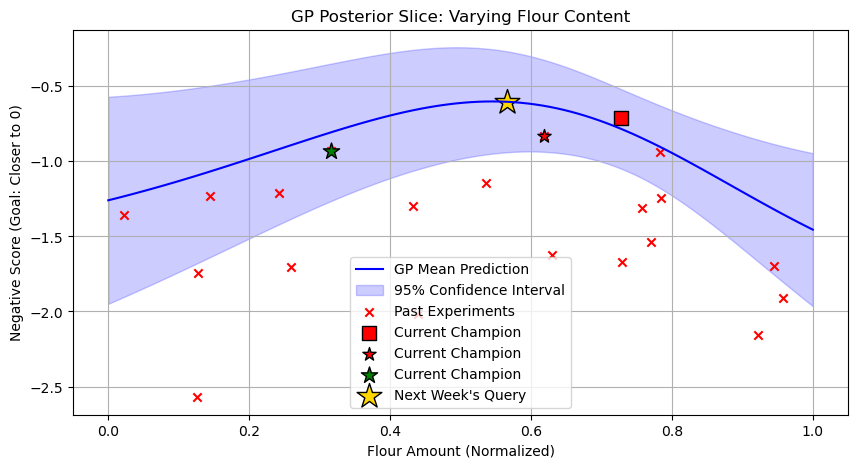

In [18]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Create a 'test' grid for the X-axis (Flour)
x_axis = np.linspace(0, 1, 100).reshape(-1, 1)

# 2. Fix the other 4 ingredients (using your current best or EI suggestion)
# Let's use the EI suggestion for the fixed values
# fixed_values = [0.030, 0.915, 0.958, 0.083] 
# fixed_values =  [0.03013267, 0.91531507, 0.95841378, 0.08393906]
next_suggested = ei_next_query
fixed_values = next_suggested[1:]

# 3. Combine into a 5D input: [varied_flour, fixed_sugar, fixed_eggs, ...]
X_plot = np.hstack([x_axis, np.tile(fixed_values, (100, 1))])

# 4. Predict mean and standard deviation
y_mean, y_std = gp.predict(X_plot, return_std=True)
y_pred_new = gp.predict(next_suggested.reshape(1, -1))


x_range = np.linspace(0, 1, 100).reshape(-1, 1)
X_plot = np.hstack([x_range, np.tile(next_suggested[1:], (100, 1))])
mu, std = gp.predict(X_plot, return_std=True)
y_pred_new = gp.predict(next_suggested.reshape(1, -1))

# 5. Plotting
plt.figure(figsize=(10, 5))
plt.plot(x_axis, y_mean, 'b-', label='GP Mean Prediction')
plt.fill_between(x_axis.flatten(), 
                 y_mean - 1.96 * y_std, 
                 y_mean + 1.96 * y_std, 
                 alpha=0.2, color='blue', label='95% Confidence Interval')

# Optional: Plot your actual data points (projected onto the Flour axis)
plt.scatter(X[:, 0], y, c='red', marker='x', label='Past Experiments')
plt.scatter(x_best[0], y_best, c='red', marker='s', s=100, label='Current Champion', edgecolors='black')
plt.scatter(x_second_best[0], y_second_best, c='red', marker='*', s=100, label='Current Champion', edgecolors='black')
plt.scatter(x_third_best[0], y_third_best, c='green', marker='*', s=150, label='Current Champion', edgecolors='black')
plt.scatter(next_suggested[0], y_pred_new, c='gold', marker='*', s=350, label='Next Week\'s Query', edgecolors='black')


plt.title('GP Posterior Slice: Varying Flour Content')
plt.xlabel('Flour Amount (Normalized)')
plt.ylabel('Negative Score (Goal: Closer to 0)')
plt.legend()
plt.grid(True)
plt.show()

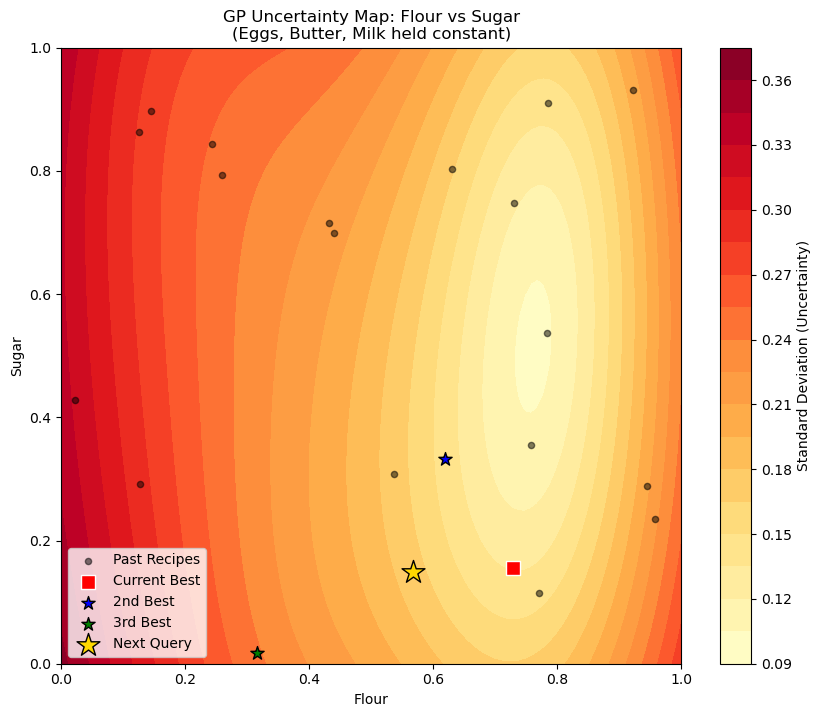

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor

# 1. Setup the Grid for the "Slice" (Flour vs Sugar)
res = 100
x_axis = np.linspace(0, 1, res)
y_axis = np.linspace(0, 1, res)
X_mesh, Y_mesh = np.meshgrid(x_axis, y_axis)

# 2. Fix the other 3 ingredients at your suggested 'next' values
# next_suggested = [0.4445, 0.0301, 0.9153, 0.9584, 0.0839]
#  x1     x2    x3    x4      x5
# flour sugar  eggs  butter  milk
# [0.44454642 0.03013267 0.91531507 0.95841378 0.08393906]
# eggs_fix, butter_fix, milk_fix = 0.91531507, 0.95841378, 0.08393906
eggs_fix, butter_fix, milk_fix = next_suggested[2], next_suggested[3], next_suggested[4]

# Combine into a 5D grid: [Flour, Sugar, Eggs(fix), Butter(fix), Milk(fix)]
grid_5d = np.c_[X_mesh.ravel(), Y_mesh.ravel(), 
                np.full(res**2, eggs_fix), 
                np.full(res**2, butter_fix), 
                np.full(res**2, milk_fix)]

# 3. Predict Uncertainty (Standard Deviation)
# Assuming 'gp' is your fitted GaussianProcessRegressor
_, std = gp.predict(grid_5d, return_std=True)
Z_std = std.reshape(res, res)


# 5. Plotting
plt.figure(figsize=(10, 8))
contour = plt.contourf(X_mesh, Y_mesh, Z_std, levels=20, cmap='YlOrRd')
plt.colorbar(contour, label='Standard Deviation (Uncertainty)')

# Mark Past Experiments
plt.scatter(X[:, 0], X[:, 1], c='black', s=20, alpha=0.5, label='Past Recipes')

# Mark Current Best (Red Square)
plt.scatter(x_best[0], x_best[1], c='red', marker='s', s=100, edgecolors='white', label='Current Best')
plt.scatter(x_second_best[0], x_second_best[1], c='blue', marker='*', s=100, edgecolors='black', label='2nd Best')
plt.scatter(x_third_best[0], x_third_best[1], c='green', marker='*', s=100, edgecolors='black', label='3rd Best')

# Mark Next Suggested (Gold Star)
plt.scatter(next_suggested[0], next_suggested[1], c='gold', marker='*', s=300, edgecolors='black', label='Next Query')


plt.title('GP Uncertainty Map: Flour vs Sugar\n(Eggs, Butter, Milk held constant)')
plt.xlabel('Flour')
plt.ylabel('Sugar')
plt.legend()
plt.show()

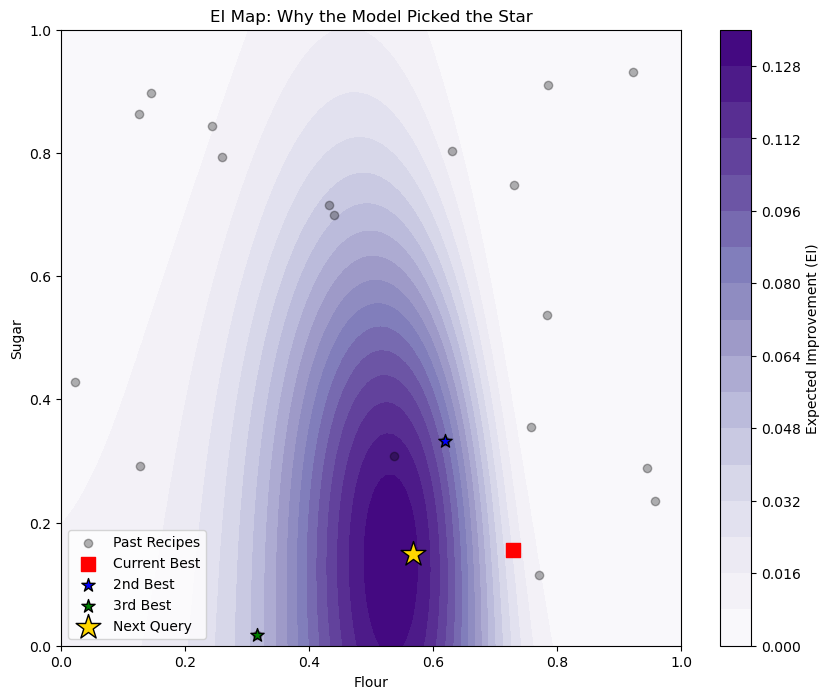

In [14]:
from scipy.stats import norm

def calculate_ei(x_grid, gp, y_best, xi=0.01):
    mu, sigma = gp.predict(x_grid, return_std=True)
    mu = mu.reshape(-1, 1)
    sigma = sigma.reshape(-1, 1)
    with np.errstate(divide='ignore'):
        imp = mu - y_best - xi
        Z = imp / sigma
        ei = imp * norm.cdf(Z) + sigma * norm.pdf(Z)
        ei[sigma <= 0.0] = 0.0
    return ei

# 1. Create the grid (Flour vs Sugar)
res = 100
x_vals = np.linspace(0, 1, res)
y_vals = np.linspace(0, 1, res)
X_m, Y_m = np.meshgrid(x_vals, y_vals)

# 2. Fix Eggs, Butter, Milk at the suggested next values
# fixed_dims = [0.9153, 0.9584, 0.0839]

# 2. Fix Eggs, Butter, Milk at the suggested next values
# fixed_dims = [0.9153, 0.9584, 0.0839]
# 2. Fix the other 3 ingredients at your suggested 'next' values
#  x1     x2    x3    x4      x5
# flour sugar  eggs  butter  milk
# [0.44454642 0.03013267 0.91531507 0.95841378 0.08393906]
fixed_dims = ei_next_query[2:]

grid_points = np.c_[X_m.ravel(), Y_m.ravel(), 
                    np.full(res**2, fixed_dims[0]),
                    np.full(res**2, fixed_dims[1]),
                    np.full(res**2, fixed_dims[2])]

# 3. Calculate EI across the grid
y_best = np.max(y) # Your current champion (-0.714)
z_ei = calculate_ei(grid_points, gp, y_best).reshape(res, res)

# 4. Plot the EI Map
plt.figure(figsize=(10, 8))
cp = plt.contourf(X_m, Y_m, z_ei, levels=20, cmap='Purples')
plt.colorbar(cp, label='Expected Improvement (EI)')

# Mark Past Samples
plt.scatter(X[:, 0], X[:, 1], c='black', alpha=0.3, label='Past Recipes')

# Mark Current Best (Red Square)
plt.scatter(X[best_idx, 0], X[best_idx, 1], c='red', marker='s', s=100, label='Current Best')
plt.scatter(x_second_best[0], x_second_best[1], c='blue', marker='*', s=100, edgecolors='black', label='2nd Best')
plt.scatter(x_third_best[0], x_third_best[1], c='green', marker='*', s=100, edgecolors='black', label='3rd Best')

# Mark Next Query (Gold Star)
plt.scatter(next_suggested[0], next_suggested[1], c='gold', marker='*', s=350, edgecolors='black', label='Next Query')

plt.title('EI Map: Why the Model Picked the Star')
plt.xlabel('Flour')
plt.ylabel('Sugar')
plt.legend()
plt.show()

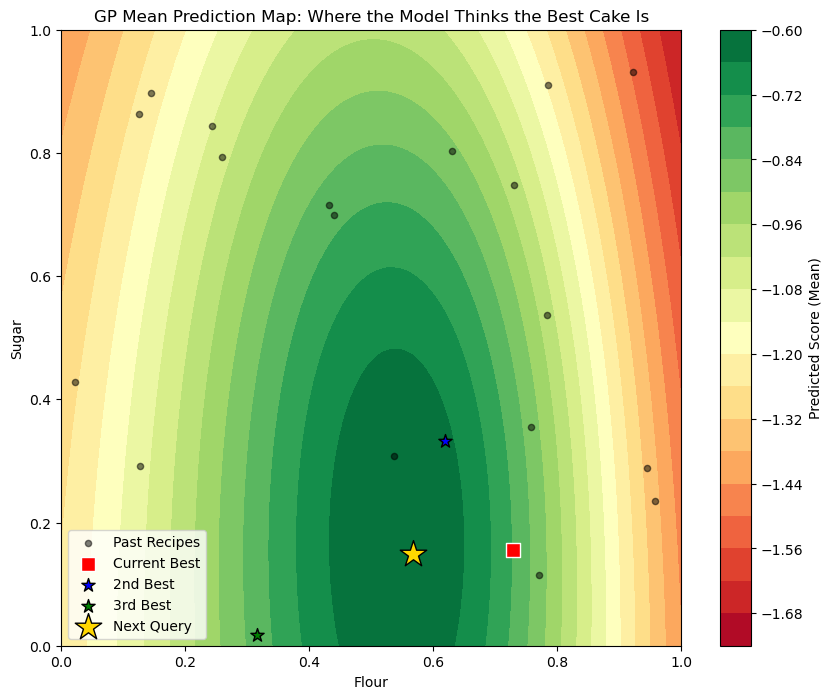

In [15]:
# Assuming your grid_5d, X_mesh, and Y_mesh are already defined as before

# 1. Predict the Mean Score
# In scikit-learn, gp.predict returns (mean, std) if return_std=True
mu, _ = gp.predict(grid_5d, return_std=True)
Z_mu = mu.reshape(res, res)

# 2. Plotting the Mean Map
plt.figure(figsize=(10, 8))
# We use 'RdYlGn' (Red-Yellow-Green) because higher scores are "better/greener"
contour_mu = plt.contourf(X_mesh, Y_mesh, Z_mu, levels=20, cmap='RdYlGn')
plt.colorbar(contour_mu, label='Predicted Score (Mean)')

# Mark Past Experiments
plt.scatter(X[:, 0], X[:, 1], c='black', s=20, alpha=0.5, label='Past Recipes')

# Mark Current Best (Red Square)
plt.scatter(x_best[0], x_best[1], c='red', marker='s', s=100, edgecolors='white', label='Current Best')
plt.scatter(x_second_best[0], x_second_best[1], c='blue', marker='*', s=100, edgecolors='black', label='2nd Best')
plt.scatter(x_third_best[0], x_third_best[1], c='green', marker='*', s=100, edgecolors='black', label='3rd Best')

# Mark Next Suggested (Gold Star)
plt.scatter(next_suggested[0], next_suggested[1], c='gold', marker='*', s=400, edgecolors='black', label='Next Query')

plt.title('GP Mean Prediction Map: Where the Model Thinks the Best Cake Is')
plt.xlabel('Flour')
plt.ylabel('Sugar')
plt.legend()
plt.show()

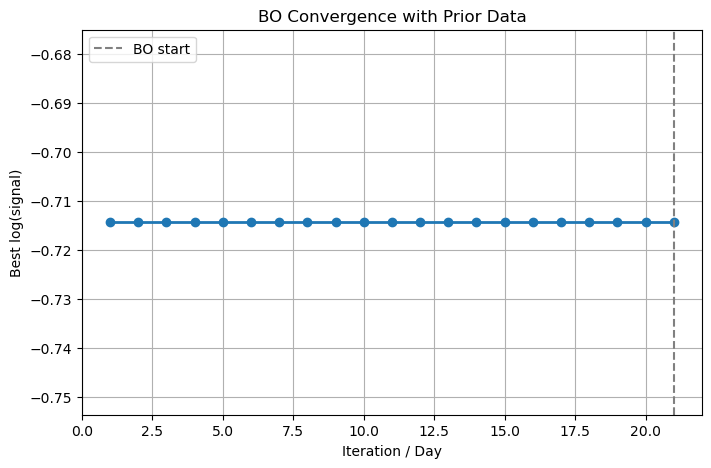

In [16]:
# Convergent Plot

# week 1
# 0.315938	0.017065	0.899154	0.923548	0.050946	-0.931978

# y_observed =y[20:] 
y_observed = y

iterations = np.arange(1, len(y_observed) + 1)
bo_best_y = np.maximum.accumulate(y_observed)

bo_start_idx = 20  # zero-based index of first BO point

plt.figure(figsize=(8,5))
plt.plot(iterations, bo_best_y, marker='o', linewidth=2)

# Vertical line separating phases
plt.axvline(x=bo_start_idx + 1, color='gray', linestyle='--', label='BO start')

plt.xlabel("Iteration / Day")
plt.ylabel("Best log(signal)")
plt.title("BO Convergence with Prior Data")
plt.grid(True)
plt.legend()

plt.show()



In [17]:
# Summary: Your "Big 5" Visuals
# You now have a complete, report:
# 2D Mean Map: The Vision.
# 2D Uncertainty Map: The Honesty.
# 2D EI Map: The Logic.
# 1D Posterior Slice: The Precision (Flour sensitivity).
# Convergence Plot: The History.

In [ ]:
# Observation 
# expected_improvement with xi: 0.01
# Current Best y: -0.7142649478202404
# Suggested next: [0.56646661 0.14938455 0.46916605 0.83112722 0.01548246]